# Baseline — Regressão Linear

Modelo mais simples (piso da comparação). Mesmo `data_prep`/CV/LOPO da DNN. Mede quanto do sinal é **linear**.

## Setup

In [1]:
import os, sys
# garante o cwd na raiz do repo (onde ficam data/ e support_scripts/)
while not os.path.isdir('support_scripts') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.append('support_scripts')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import data_prep as dp, sk_eval

d = dp.get_data()
print(f"{len(d['df'])} animais | {len(d['scale_cols'])} preditores | "
      f"{d['groups'].value_counts().to_dict()}")
from sklearn.linear_model import LinearRegression

245 animais | 9 preditores | {'elvis': 113, 'humberto': 71, 'sonico': 61}


## CV 10-fold + LOPO (grava em `results/model_comparison.csv`)

In [2]:
res = sk_eval.registrar('Linear', LinearRegression, scale=True, d=d)
res['lopo']

Linear: CV R2 sem=0.424 / com jitter=0.424  | MAE=0.0647
  LOPO R2: {'elvis': -1.72, 'sonico': -196.41, 'humberto': -0.78}


,testa,MAE,RMSE,R2
0,elvis,0.1194,0.1511,-1.7192
1,sonico,0.7753,1.0586,-196.4093
2,humberto,0.2066,0.2228,-0.7783


## Predito × real (out-of-fold)

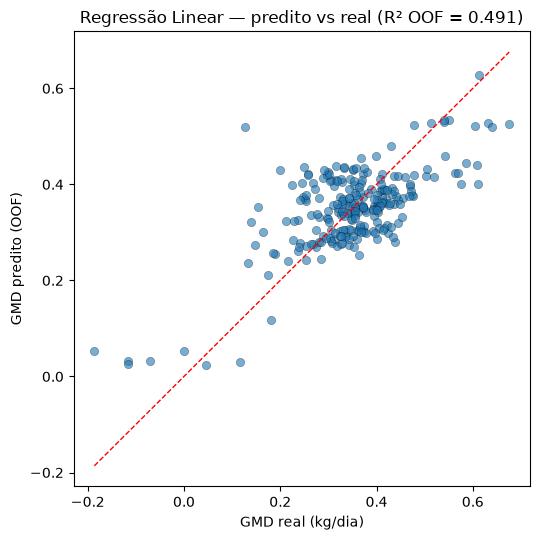

In [3]:
y = d['df'][dp.TARGET].values
yp = sk_eval.oof(d, LinearRegression, scale=True)
r2 = dp.metrics(y, yp)['R2']
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y, yp, alpha=.6, edgecolor='k', linewidth=.3)
lims = [min(y.min(), yp.min()), max(y.max(), yp.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('GMD real (kg/dia)'); ax.set_ylabel('GMD predito (OOF)')
ax.set_title(f'Regressão Linear — predito vs real (R² OOF = {r2:.3f})')
plt.tight_layout(); plt.show()